1. Load the Customer Segmentation Tutorial Dataset from Kaggle into a Jupyter Notebook and display the first 10 rows using pandas.


In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72


2. Use pandas to check for missing values in the Age, Annual Income, and Spending Score columns, and print the total number of missing values for each.


In [2]:
print("Missing Values:\n")

print(df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].isnull().sum())

Missing Values:

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


3. Create a scatterplot of Annual Income vs Spending Score using matplotlib or seaborn to visualize how customers are distributed.<br><br><em><strong>Hint:</strong> Use seaborn.scatterplot() or plt.scatter().</em>


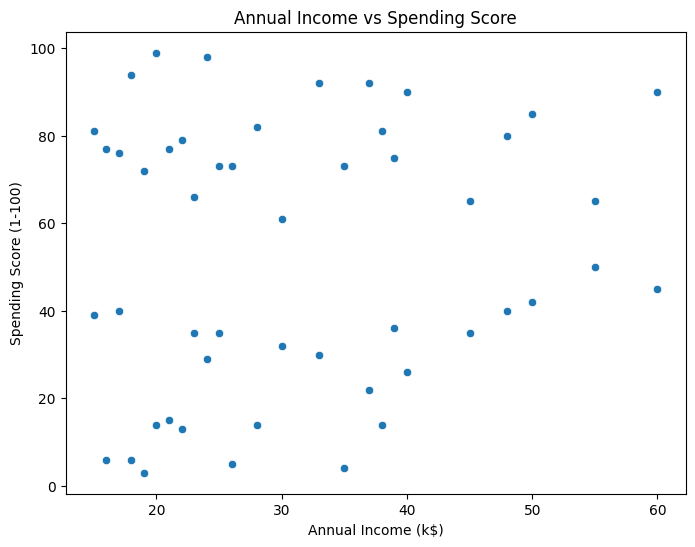

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")

plt.show()

4. Generate a heatmap of the correlation matrix for the numerical features in the dataset using seaborn, and interpret which two features are most strongly correlated.


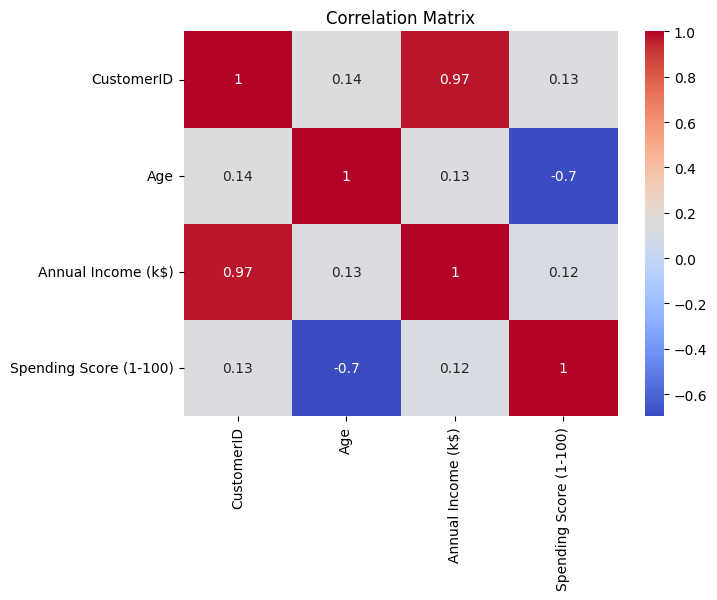

                        CustomerID       Age  Annual Income (k$)  \
CustomerID                1.000000  0.137879            0.972052   
Age                       0.137879  1.000000            0.131198   
Annual Income (k$)        0.972052  0.131198            1.000000   
Spending Score (1-100)    0.134562 -0.698215            0.122297   

                        Spending Score (1-100)  
CustomerID                            0.134562  
Age                                  -0.698215  
Annual Income (k$)                    0.122297  
Spending Score (1-100)                1.000000  


In [4]:
plt.figure(figsize=(7,5))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

print(corr)

5. Apply K-Means clustering (from sklearn.cluster) to segment customers into 3 groups based on Annual Income and Spending Score, then add a new column 'Cluster' to your DataFrame with the assigned cluster for each customer.<br><br><em><strong>Constraint:</strong> Use only the two features for clustering, and set random_state=42 for reproducibility.</em>

In [5]:
from sklearn.cluster import KMeans

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        1  
2        2  
3        1  
4        2  


In [6]:
print(df["Cluster"].value_counts())

Cluster
1    23
2    19
0     8
Name: count, dtype: int64


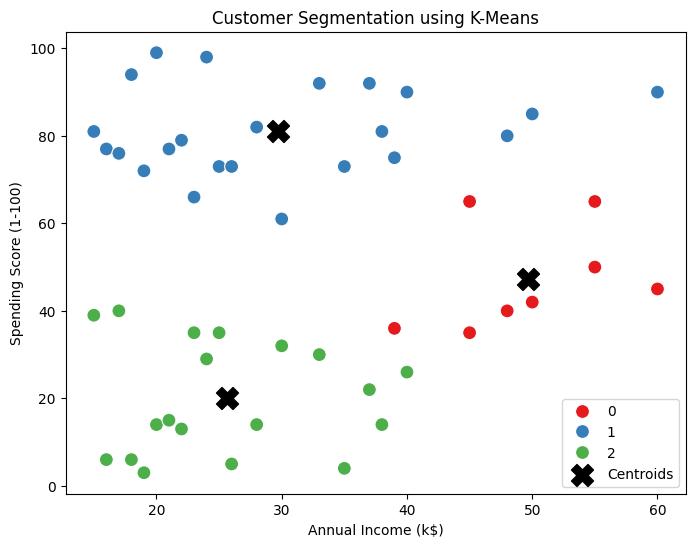

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")

plt.legend()

plt.show()